In [ ]:
import poreflow as pf
from poreflow.steps import changepoint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from database import AA_CLASS

df = pd.read_csv('features.csv')

In [10]:
data_path = "nanopore_trace_database.csv"

db = pd.read_csv(data_path)
SAMPLING_FREQ = 5000 # needs to match what i used to generate

In [11]:
trace_id = 0
trace = db[db['trace_id'] == trace_id]
current = trace['current_pA'].to_numpy()
time_ms = trace['time_ms'].to_numpy()


# steps = changepoint.get_steps(current, sfreq=SAMPLING_FREQ, sensitivity=0.3, min_level_length=10)
# print(steps)

In [12]:
for s in [1.0, 0.5, 0.3, 0.2, 0.1]:
    steps = changepoint.get_steps(current, sfreq=SAMPLING_FREQ, sensitivity=s)
    print(f"sensitivity={s}: {len(steps)} steps detected (ground truth: 275)")

sensitivity=1.0: 321 steps detected (ground truth: 275)
sensitivity=0.5: 603 steps detected (ground truth: 275)
sensitivity=0.3: 1083 steps detected (ground truth: 275)
sensitivity=0.2: 1499 steps detected (ground truth: 275)
sensitivity=0.1: 2163 steps detected (ground truth: 275)


In [13]:
steps = changepoint.get_steps(current, sfreq=SAMPLING_FREQ, sensitivity=0.3, min_level_length=10)
print(steps)

     start_idx  end_idx       std        mean  n_pts  start_time  end_time  \
0            0       42  1.221080   96.839435     42      0.0000    0.0084   
1           42       73  1.172466   88.708620     31      0.0084    0.0146   
2           73      120  1.030476   85.459912     47      0.0146    0.0240   
3          120      130  1.164877   79.888411     10      0.0240    0.0260   
4          130      145  0.786303   79.006709     15      0.0260    0.0290   
..         ...      ...       ...         ...    ...         ...       ...   
431       8960     8975  1.421051  104.573138     15      1.7920    1.7950   
432       8975     8985  0.811547  102.881385     10      1.7950    1.7970   
433       8985     9010  1.023094   98.558531     25      1.7970    1.8020   
434       9010     9021  0.976640   85.465474     11      1.8020    1.8042   
435       9021     9035  0.934824   86.567089     14      1.8042    1.8070   

     dwell_time  
0        0.0084  
1        0.0062  
2        

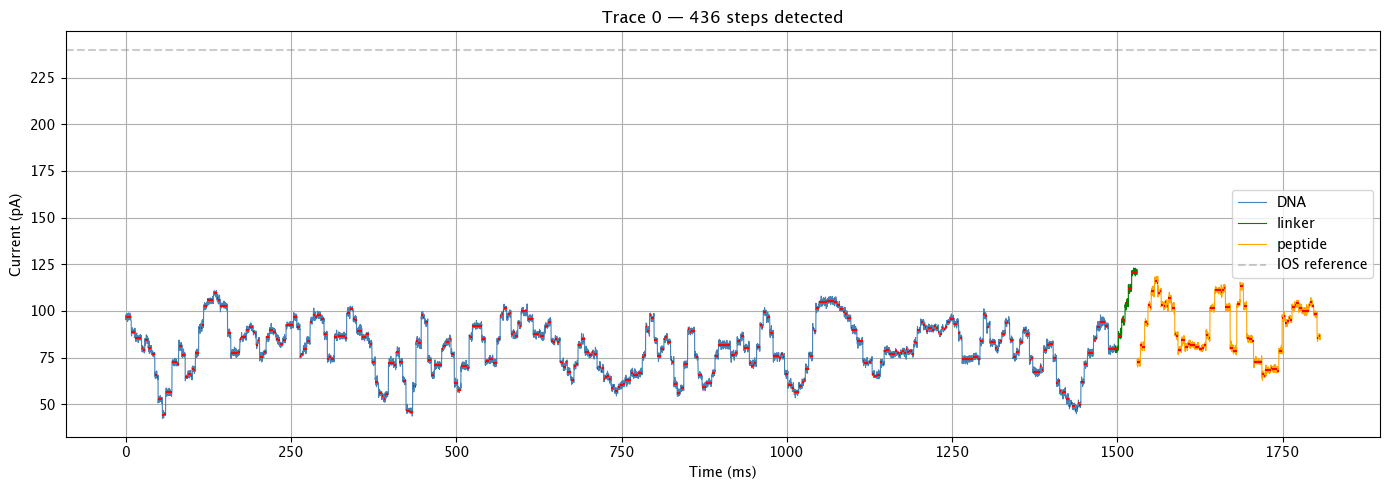

In [14]:
import matplotlib.pyplot as plt
from plot_trace import plot_trace

fig, ax = plt.subplots(figsize=(14, 5))

plot_trace(db, trace_id, ax=ax)

for _, step in steps.iterrows():
    start = int(step[pf.START_IDX_COL])
    end   = int(step[pf.END_IDX_COL])
    ax.hlines(step[pf.MEAN_COL], time_ms[start], time_ms[end - 1],
              color='red', linewidth=1.5)

ax.set_title(f'Trace {trace_id} — {len(steps)} steps detected')
plt.tight_layout()
plt.show()

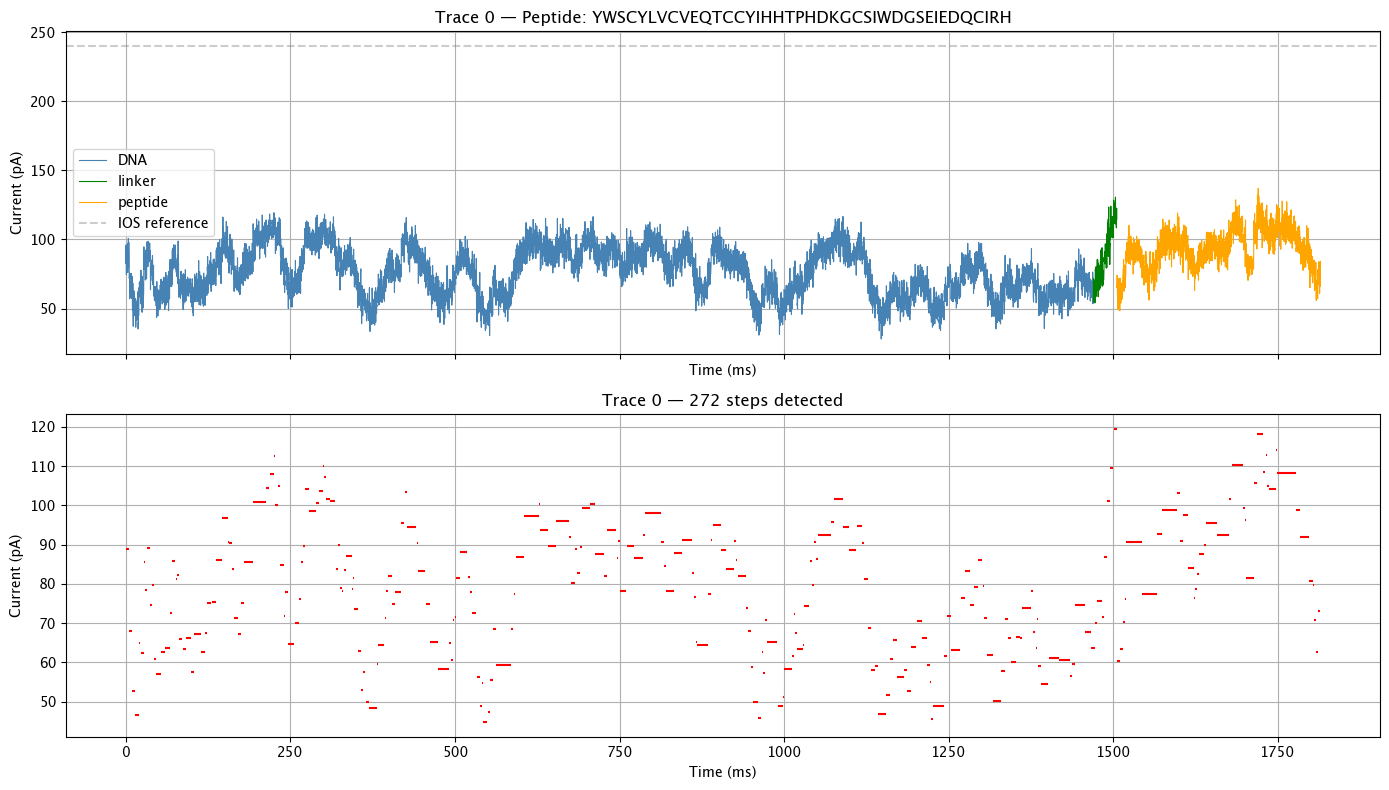

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: raw trace coloured by region
plot_trace(db, trace_id, ax=ax1)

# Bottom: step levels only
for _, step in steps.iterrows():
    start = int(step[pf.START_IDX_COL])
    end   = int(step[pf.END_IDX_COL])
    ax2.hlines(step[pf.MEAN_COL], time_ms[start], time_ms[end - 1],
               color='red', linewidth=1.5)

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Current (pA)')
ax2.set_title(f'Trace {trace_id} — {len(steps)} steps detected')
ax2.grid(True)

plt.tight_layout()
plt.show()

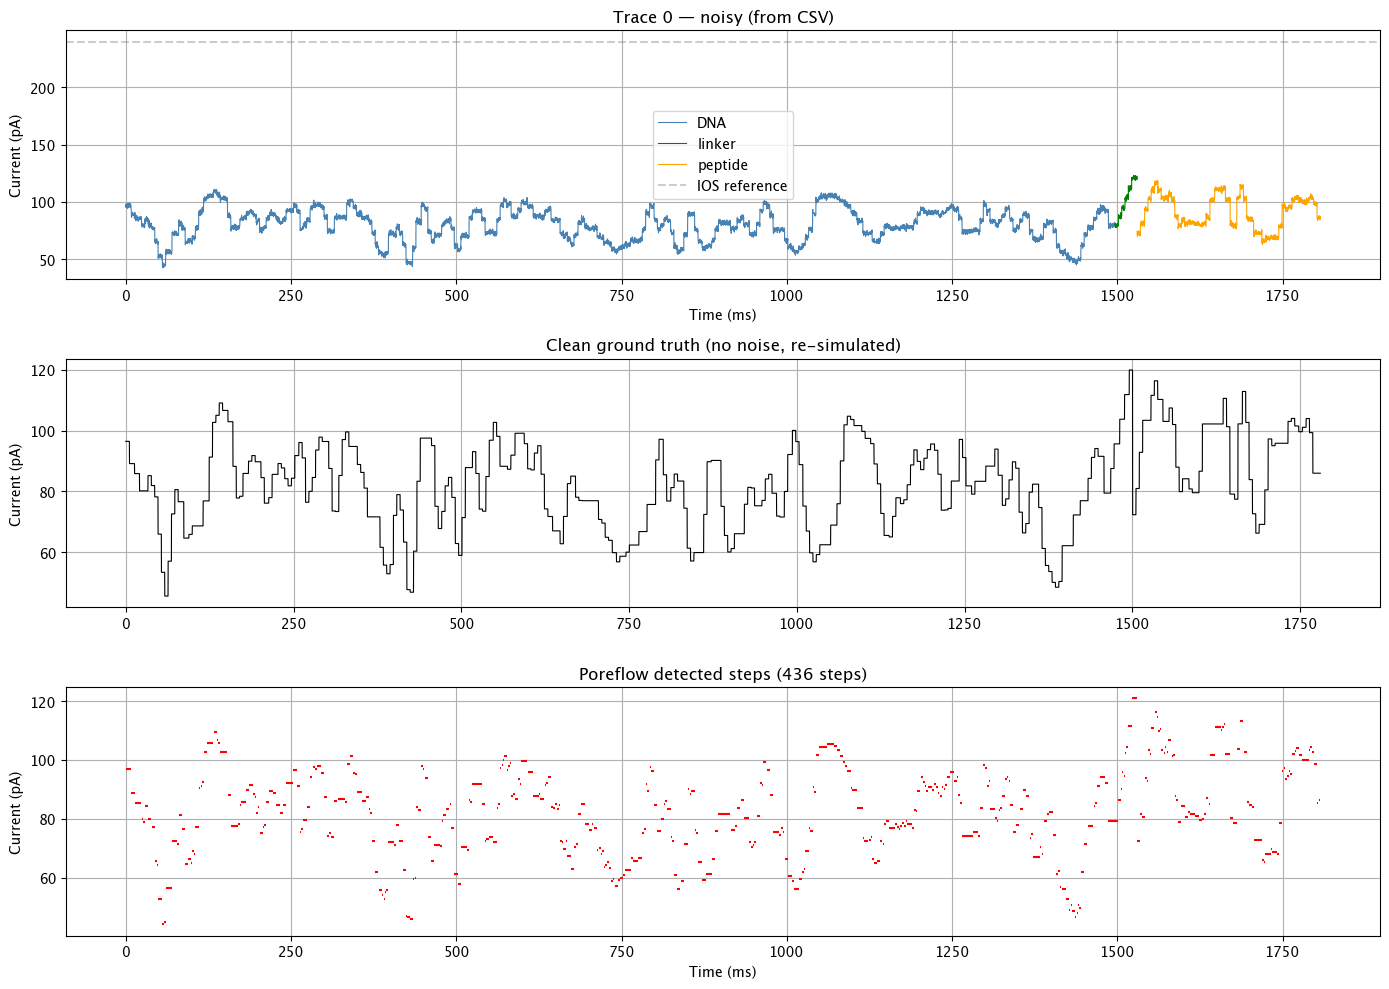

In [15]:
from database import (
    peptide_to_cdna, simulate_dna_region, simulate_linker_region,
    simulate_peptide_region, IOS, PEP_BASELINE, SAMPLING_FREQ
)

trace_id = 0
trace = db[db['trace_id'] == trace_id]
peptide = trace['peptide_sequence'].iloc[0]

# Recompute clean (noiseless) levels
cdna = peptide_to_cdna(peptide)
dna_clean    = simulate_dna_region(cdna)
linker_clean = simulate_linker_region(dna_clean[-1], PEP_BASELINE * IOS)
pep_clean    = simulate_peptide_region(peptide)

clean_current = np.concatenate([dna_clean, linker_clean, pep_clean])
clean_time_ms = np.arange(len(clean_current)) * (1000 / SAMPLING_FREQ)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

# 1. Noisy trace
plot_trace(db, trace_id, ax=ax1)
ax1.set_title(f'Trace {trace_id} — noisy (from CSV)')

# 2. Clean ground truth
ax2.plot(clean_time_ms, clean_current, color='black', linewidth=0.8)
ax2.set_ylabel('Current (pA)')
ax2.set_title('Clean ground truth (no noise, re-simulated)')
ax2.grid(True)

# 3. Poreflow-detected steps
current = trace['current_pA'].to_numpy()
time_ms = trace['time_ms'].to_numpy()
for _, step in steps.iterrows():
    start = int(step[pf.START_IDX_COL])
    end   = int(step[pf.END_IDX_COL])
    ax3.hlines(step[pf.MEAN_COL], time_ms[start], time_ms[end - 1],
               color='red', linewidth=1.5)
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Current (pA)')
ax3.set_title(f'Poreflow detected steps ({len(steps)} steps)')
ax3.grid(True)

plt.tight_layout()
plt.show()

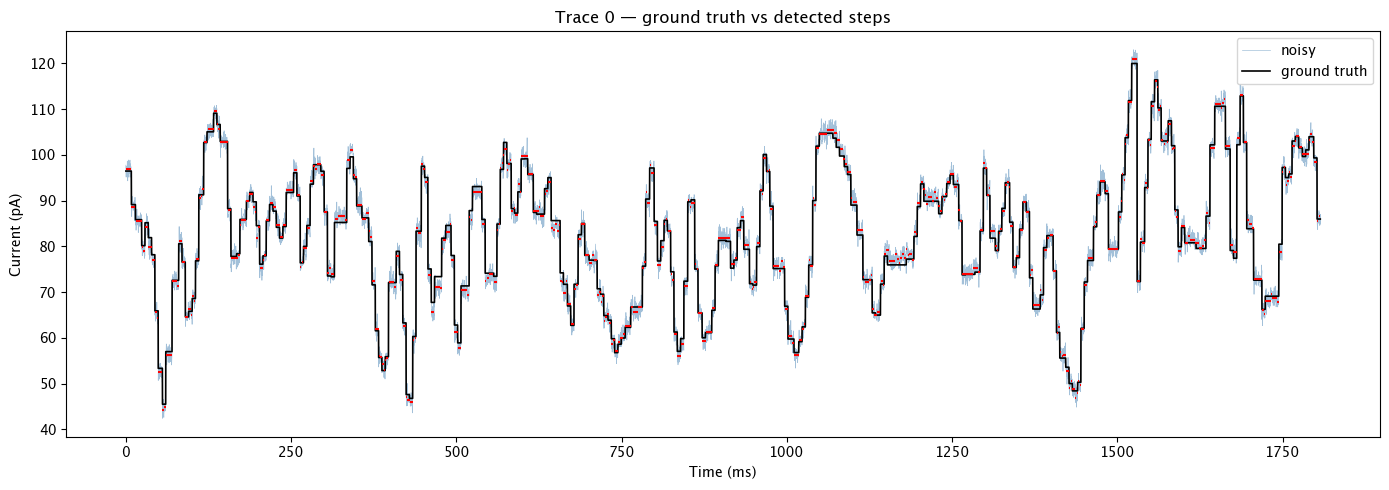

In [16]:
trace = db[db['trace_id'] == trace_id]
time_ms = trace['time_ms'].to_numpy()
current = trace['current_pA'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))

# Noisy trace
ax.plot(time_ms, current, color='steelblue', linewidth=0.5, alpha=0.5, label='noisy')

# Ground truth clean levels
ax.plot(time_ms, trace['clean_pA'].to_numpy(), color='black', linewidth=1.2, label='ground truth')

# Poreflow detected steps
for _, step in steps.iterrows():
    start = int(step[pf.START_IDX_COL])
    end   = int(step[pf.END_IDX_COL])
    ax.hlines(step[pf.MEAN_COL], time_ms[start], time_ms[end - 1],
              color='red', linewidth=1.5)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Current (pA)')
ax.set_title(f'Trace {trace_id} — ground truth vs detected steps')
ax.legend()
plt.tight_layout()
plt.show()


In [17]:
# ground trush steps are where clean_pa changes value


trace = db[db['trace_id'] == trace_id]
clean = trace['clean_pA'].to_numpy()
time_ms = trace['time_ms'].to_numpy()

change_idx = np.where(np.diff(clean) != 0)[0] + 1
gt_starts = np.concatenate([[0], change_idx]) # first step starts at index 0
gt_ends = np.concatenate([change_idx, [len(clean)]]) # last steps ends at final sample
gt_levels = clean[gt_starts]

gt_steps = pd.DataFrame({
    'start_idx': gt_starts,
    'end_idx': gt_ends,
    'mean': gt_levels,
    'dwell_time':(gt_ends - gt_starts)/SAMPLING_FREQ,
})

In [10]:
print(f"Ground truth: {len(gt_steps)} steps")
print(gt_steps.head(10))
print(f"\nPoreflow detected: {len(steps)} steps")
print(steps[['start_idx', 'end_idx', 'mean', 'dwell_time']].head(10))



Ground truth: 275 steps
   start_idx  end_idx       mean  dwell_time
0          0       25  85.694115      0.0050
1         25       50  69.723283      0.0050
2         50       75  50.683722      0.0050
3         75      100  46.917526      0.0050
4        100      136  61.617147      0.0072
5        136      161  83.257041      0.0050
6        161      186  89.518082      0.0050
7        186      211  78.701873      0.0050
8        211      236  63.725616      0.0050
9        236      261  61.014109      0.0050

Poreflow detected: 272 steps
   start_idx  end_idx       mean  dwell_time
0          0       26  88.885209      0.0052
1         26       50  68.083427      0.0048
2         50       68  52.590744      0.0036
3         68      100  46.594637      0.0064
4        100      112  64.968498      0.0024
5        112      136  62.399784      0.0048
6        136      148  85.604337      0.0024
7        148      159  78.424428      0.0022
8        159      187  89.155567      0.0056
9

In [27]:
print("\nGround truth levels vs Poreflow detected levels:")
print(f"{'GT mean':>10}  {'PF mean':>10}  {'diff':>8}")
for gt, pf_row in zip(gt_steps['mean'], steps[pf.MEAN_COL]):
    print(f"{gt:>10.2f}  {pf_row:>10.2f}  {abs(gt - pf_row):>8.2f}")


Ground truth levels vs Poreflow detected levels:
   GT mean     PF mean      diff
     85.69       88.89      3.19
     69.72       68.08      1.64
     50.68       52.59      1.91
     46.92       46.59      0.32
     61.62       64.97      3.35
     83.26       62.40     20.86
     89.52       85.60      3.91
     78.70       78.42      0.28
     63.73       89.16     25.43
     61.01       74.72     13.71
     64.88       79.75     14.86
     75.97       60.90     15.07
     87.08       57.06     30.02
     84.32       62.67     21.65
     68.56       63.67      4.89
     60.11       72.60     12.49
     65.56       85.79     20.23
     72.84       81.30      8.46
     74.65       82.16      7.51
     78.21       65.88     12.33
     87.01       63.33     23.68
     92.27       66.22     26.05
     97.32       57.61     39.71
     95.35       67.33     28.01
     85.65       62.60     23.05
     73.78       67.58      6.21
     71.06       75.03      3.97
     72.45       75.37    

In [12]:
help(changepoint.get_steps)

Help on function get_steps in module poreflow.steps.changepoint:

get_steps(i: numpy.ndarray, sfreq: float, **kwargs) -> poreflow.structures.steps.StepsDataFrame



In [14]:
import inspect
print(inspect.getsource(changepoint.get_steps))

def get_steps(i: np.ndarray, sfreq: float, **kwargs) -> pf.StepsDataFrame:
    results = get_step_features(i, **kwargs)
    return format_steps_df(*results, sfreq=sfreq)



In [15]:
print(inspect.getsource(changepoint.get_step_features))

def get_step_features(
    data: np.ndarray,
    sensitivity: float = 1,
    min_level_length: int = 2,
) -> tuple[np.ndarray, np.ndarray]:
    transitions = find_transitions(data, min_level_length, sensitivity)

    features = np.zeros((2, len(transitions) - 1))

    for j, start, stop in iter_transitions(transitions):
        features[0, j] = np.mean(data[start:stop])
        features[1, j] = np.std(data[start:stop])

    return transitions, features



sensitivity=1.0: 158 steps detected (ground truth: 275)
sensitivity=0.5: 329 steps detected (ground truth: 275)
sensitivity=0.3: 668 steps detected (ground truth: 275)
sensitivity=0.2: 998 steps detected (ground truth: 275)
sensitivity=0.1: 1674 steps detected (ground truth: 275)


In [ ]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in df.groupby('phys_class'):
    grp['mean_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Mean current (pA)')
ax.set_title('Mean current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
df.boxplot(column='mean_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Mean current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(df.groupby('phys_class')['mean_current'].describe().round(2))